In [14]:
import pandas as pd
import numpy as np

## 1. Introdução

### Objetivo da análise


****
## 2. Carregamento e exploração dos dados
Nesta etapa, o conjunto de dados do Titanic é carregado e explorado inicialmente, com o objetivo de compreender sua estrutura, suas variáveis e a presença de possíveis valores ausentes. Essa análise inicial é importante para identificar características que deverão ser consideradas nas etapas posteriores de preparação dos dados e aplicação do algoritmo K-Means.

In [4]:
titanic = pd.read_csv('https://raw.githubusercontent.com/EMbeDS-education/IPDPP-GSSI-20202021/main/datasets/TITANIC.csv')

In [ ]:
titanic.head()

O conjunto de dados possui informações relacionadas aos passageiros do Titanic, incluindo características pessoais, informações da viagem e dados relacionados à sobrevivência. A seguir, são apresentadas brevemente as variáveis presentes no conjunto de dados.
| Variável    | Descrição                                                                       |
| ----------- | ------------------------------------------------------------------------------- |
| `pclass`    | Classe em que o passageiro estava viajando.                                     |
| `survived`  | Indica se o passageiro sobreviveu ao naufrágio.                                 |
| `Residence` | Código relacionado ao local de residência do passageiro.                        |
| `name`      | Nome do passageiro.                                                             |
| `age`       | Idade do passageiro.                                                            |
| `sibsp`     | Quantidade de irmãos ou cônjuges que estavam a bordo.                           |
| `parch`     | Quantidade de pais ou filhos que estavam a bordo.                               |
| `ticket`    | Número ou identificação do bilhete do passageiro.                               |
| `fare`      | Valor pago pelo passageiro pela passagem.                                       |
| `cabin`     | Identificação da cabine do passageiro.                                          |
| `embarked`  | Porto em que o passageiro embarcou.                                             |
| `boat`      | Identificação do bote salva-vidas utilizado pelo passageiro, quando disponível. |
| `body`      | Identificação associada ao corpo do passageiro, quando disponível.              |
| `home.dest` | Local de origem ou destino do passageiro.                                       |
| `Gender`    | Gênero do passageiro.                                                           |


Das variaveis do conjunto de dados as que chamam atenção são: <br>
```age``` que está como ```str```, mas representa idade; <br>
```fare``` que está como ```str```, mas representa uma tarifa numérica; <br>
```body``` também está como ```str```, embora represente um número/identificador.

In [ ]:
titanic.dtypes

A análise dos tipos de dados mostrou que o conjunto de dados possui variáveis numéricas e categóricas. Algumas variáveis que representam valores numéricos, como `age` e `fare`, estão armazenadas como texto (`str`) e poderão necessitar de conversão durante o pré-processamento.

Para verificar a existência de valores faltantes, foi utilizada a função `isnull().sum()`. O resultado mostrou que todas as variáveis apresentam zero valores ausentes identificados como `NaN`. Dessa forma, não foram identificados valores faltantes por esse método na etapa inicial de exploração dos dados.

In [ ]:
titanic.isnull().sum()

Para verificar a existência de registros duplicados, foi utilizada a função `duplicated().sum()`, que identificou **0 linhas duplicadas** no conjunto de dados. Dessa forma, não foi necessário remover nenhum registro por duplicidade.

In [11]:
titanic.duplicated().sum()

np.int64(0)

Inicialmente, a função `isnull().sum()` não identificou valores ausentes no conjunto de dados. Entretanto, durante uma análise mais detalhada, verificou-se que algumas variáveis possuíam valores faltantes representados como strings vazias. Dessa forma, foi necessário realizar uma verificação adicional para identificar essas ocorrências.

Foram identificados valores faltantes nas variáveis `age` (263), `fare` (1), `cabin` (1014), `embarked` (2), `boat` (823), `body` (1188) e `home.dest` (564).


In [ ]:
valoresFaltantes = ["?", "NA", "NaN", "nan", "NAN", "n/a", "N/A", "null", "NULL", "Null", " "]
for coluna in titanic.select_dtypes(include="str").columns:
    encontrados = titanic[coluna][titanic[coluna].isin(valoresFaltantes)].value_counts()

    if not encontrados.empty:
        print(f"\n{coluna}:")
        print(encontrados)

Para o tratamento dos valores faltantes, inicialmente foram consideradas as características e a quantidade de ausências de cada variável. Na variável age, os 263 valores faltantes foram substituídos pela mediana, evitando a remoção de uma quantidade significativa de registros. Na variável fare, que apresentava apenas um valor faltante, também foi utilizada a mediana.

Para a variável categórica embarked, que apresentava dois valores faltantes, foi utilizada a moda como estratégia de preenchimento. Já as variáveis cabin, boat, body e home.dest apresentaram uma quantidade elevada de valores faltantes e, por isso, não foram consideradas adequadas para utilização no agrupamento. Além disso, boat e body possuem informações relacionadas às consequências do naufrágio, podendo introduzir informações associadas à variável de sobrevivência no agrupamento. Dessa forma, essas variáveis serão desconsideradas na seleção dos atributos utilizados pelo K-Means.

In [15]:
titanic["age"] = titanic["age"].replace(" ", np.nan)
titanic["age"] = pd.to_numeric(titanic["age"])

titanic["age"] = titanic["age"].fillna(titanic["age"].median())

In [17]:
titanic["fare"] = titanic["fare"].replace(" ", np.nan)
titanic["fare"] = pd.to_numeric(titanic["fare"])

titanic["fare"] = titanic["fare"].fillna(titanic["fare"].median())

In [18]:
titanic["embarked"] = titanic["embarked"].replace(" ", np.nan)

titanic["embarked"] = titanic["embarked"].fillna(
    titanic["embarked"].mode()[0]
)

****
## 3. Pré-processamento (continuação)

### 3.1 Remoção de colunas não utilizadas

Conforme justificado na seção anterior, removemos as colunas com muitos valores faltantes (`cabin`, `boat`, `body`, `home.dest`), sendo que `boat` e `body` ainda revelam o resultado do naufrágio (**vazamento de dados**). Removemos também `name` e `ticket`, que são identificadores em texto sem utilidade para o cálculo de distâncias.

### 3.0 Bibliotecas adicionais

As etapas a seguir usam bibliotecas além de `pandas` e `numpy` (importadas acima). `random_state=42` é usado em todo lugar onde há aleatoriedade, para os resultados serem **reprodutíveis**.

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             adjusted_rand_score, normalized_mutual_info_score)

SEED = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

In [12]:
df_limpo = titanic.drop(columns=["body", "cabin", "boat", "home.dest", "name", "ticket"]).copy()
print("NaN restantes:", df_limpo.isna().sum().sum())
print("Tipos:\n", df_limpo.dtypes)
df_limpo.head()

NaN restantes: 0
Tipos:
 pclass         int64
survived       int64
Residence      int64
age          float64
sibsp          int64
parch          int64
fare         float64
embarked         str
Gender           str
dtype: object


,pclass,survived,Residence,age,sibsp,parch,fare,embarked,Gender
0,3,0,0,42.0,0,0,7.55,S,Male
1,3,0,0,13.0,0,2,20.25,S,Male
2,3,0,0,16.0,1,1,20.25,S,Male
3,3,1,0,35.0,1,1,20.25,S,Female
4,3,1,2,16.0,0,0,7.65,S,Female


### 3.2 Detecção e tratamento de valores atípicos (outliers)

Primeiro olhamos os boxplots das variáveis numéricas.

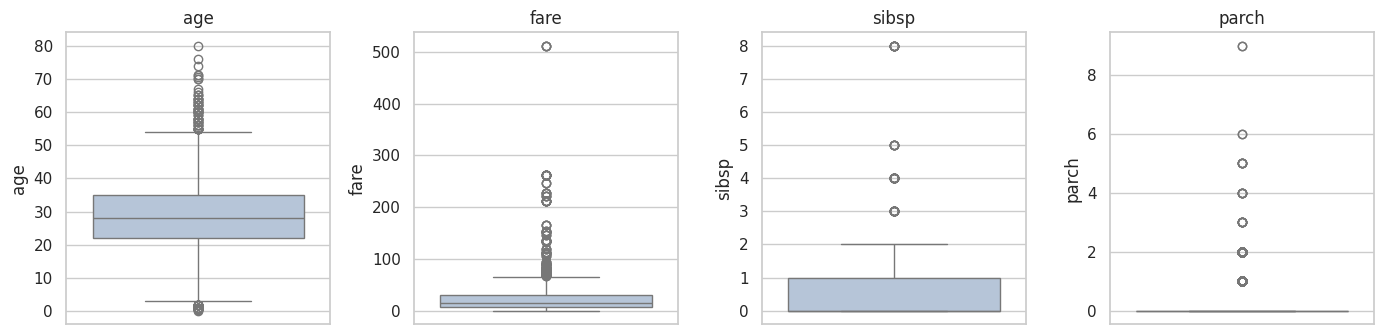

In [13]:
num_cols = ["age", "fare", "sibsp", "parch"]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, c in zip(axes, num_cols):
    sns.boxplot(y=df_limpo[c], ax=ax, color="lightsteelblue")
    ax.set_title(c)
plt.tight_layout()
plt.show()

**Método:** regra do IQR (intervalo interquartil). Valores abaixo de `Q1 − 1,5·IQR` ou acima de `Q3 + 1,5·IQR` são considerados atípicos.

**Tratamento:** em vez de **remover** linhas (perderíamos passageiros reais, principalmente de 1ª classe com tarifas altas), fazemos **winsorização**: os valores extremos são "cortados" (`clip`) nos limites. O K-Means usa distâncias e médias, por isso é muito sensível a valores extremos, e o corte reduz esse efeito mantendo todas as linhas.

- `age` e `fare`: limites pelo IQR.  
- `sibsp` e `parch`: são contagens e Q1 = Q3 = 0 (quase todos viajam sem família), então o IQR vira ≈ 0 e cortaria tudo. Para elas usamos o **percentil 99** como teto.

age: 101 outliers (limites: 2.50 a 54.50)
fare: 171 outliers (limites: -27.17 a 66.34)
sibsp: 9 valores acima do percentil 99 (teto = 5)
parch: 10 valores acima do percentil 99 (teto = 4)


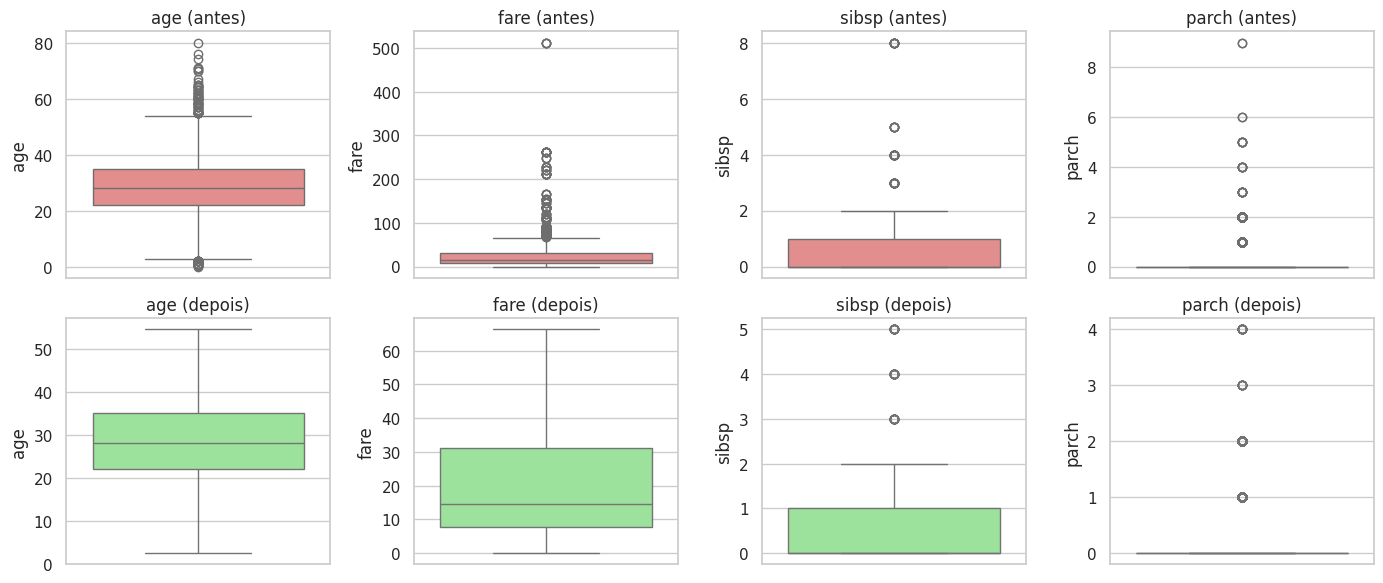

In [14]:
df_tratado = df_limpo.copy()

for c in ["age", "fare"]:
    q1, q3 = df_tratado[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df_tratado[c] < lim_inf) | (df_tratado[c] > lim_sup)).sum()
    print(f"{c}: {n_out} outliers (limites: {lim_inf:.2f} a {lim_sup:.2f})")
    df_tratado[c] = df_tratado[c].clip(lim_inf, lim_sup)

for c in ["sibsp", "parch"]:
    teto = df_tratado[c].quantile(0.99)
    n_out = (df_tratado[c] > teto).sum()
    print(f"{c}: {n_out} valores acima do percentil 99 (teto = {teto:.0f})")
    df_tratado[c] = df_tratado[c].clip(upper=teto)

# Comparação visual antes x depois
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for j, c in enumerate(num_cols):
    sns.boxplot(y=df_limpo[c], ax=axes[0, j], color="lightcoral");   axes[0, j].set_title(f"{c} (antes)")
    sns.boxplot(y=df_tratado[c], ax=axes[1, j], color="lightgreen"); axes[1, j].set_title(f"{c} (depois)")
plt.tight_layout()
plt.show()

### 3.3 Transformação de variáveis categóricas

O K-Means só trabalha com números. Usamos `pd.get_dummies` (*one-hot encoding*) nas categóricas **nominais** (`Gender`, `embarked`, `Residence`), com `drop_first=True` para evitar colunas redundantes. `pclass` já é numérica e **ordinal** (1 < 2 < 3), então fica como está.

`Residence` é guardada como código 0/1/2, mas **não tem ordem** (2 não é "mais" que 1), por isso também vira dummy.

O alvo `survived` é separado e **guardado fora** das variáveis de entrada.

In [15]:
y = df_tratado["survived"].copy()
X_bruto = df_tratado.drop(columns=["survived"])

X = pd.get_dummies(X_bruto, columns=["Gender", "embarked", "Residence"],
                   drop_first=True, dtype=int)
print("Colunas após codificação:", list(X.columns))
X.head()

Colunas após codificação: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'Gender_Male', 'embarked_Q', 'embarked_S', 'Residence_1', 'Residence_2']


,pclass,age,sibsp,parch,fare,Gender_Male,embarked_Q,embarked_S,Residence_1,Residence_2
0,3,42.0,0,0,7.55,1,0,1,0,0
1,3,13.0,0,2,20.25,1,0,1,0,0
2,3,16.0,1,1,20.25,1,0,1,0,0
3,3,35.0,1,1,20.25,0,0,1,0,0
4,3,16.0,0,0,7.65,0,0,1,0,1


### 3.4 Padronização (StandardScaler)

**Motivação:** o K-Means agrupa pela **distância euclidiana**. Sem padronizar, `fare` (valores até ~66) e `age` (até ~57) dominariam as variáveis pequenas (0/1 das dummies, `parch` etc.) só pela escala, não por importância. O `StandardScaler` coloca cada coluna com **média 0 e desvio-padrão 1**, e todas passam a contribuir de forma comparável.

In [16]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
display(X_scaled.describe().loc[["mean", "std"]].round(2))

,pclass,age,sibsp,parch,fare,Gender_Male,embarked_Q,embarked_S,Residence_1,Residence_2
mean,-0.0,-0.0,-0.0,-0.0,-0.0,0.0,-0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


****
## 4. Seleção de atributos (`SelectKBest`)

Nem todo atributo ajuda a formar grupos úteis. Usamos `SelectKBest` com dois critérios para ter uma segunda opinião:

- **ANOVA F (`f_classif`)**: mede relação linear de cada atributo com `survived`.  
- **Informação mútua (`mutual_info_classif`)**: captura também relações não lineares.

,F_score,p_valor,info_mutua
Gender_Male,507.0593,0.0000,0.1745
pclass,141.4195,0.0000,0.0469
fare,126.3218,0.0000,0.1096
embarked_S,30.3071,0.0000,0.0117
parch,15.0768,0.0001,0.0159
Residence_2,9.7638,0.0018,0.0000
Residence_1,6.8560,0.0089,0.0000
age,2.2391,0.1348,0.0378
embarked_Q,0.3377,0.5613,0.0053
sibsp,0.2544,0.6141,0.0178


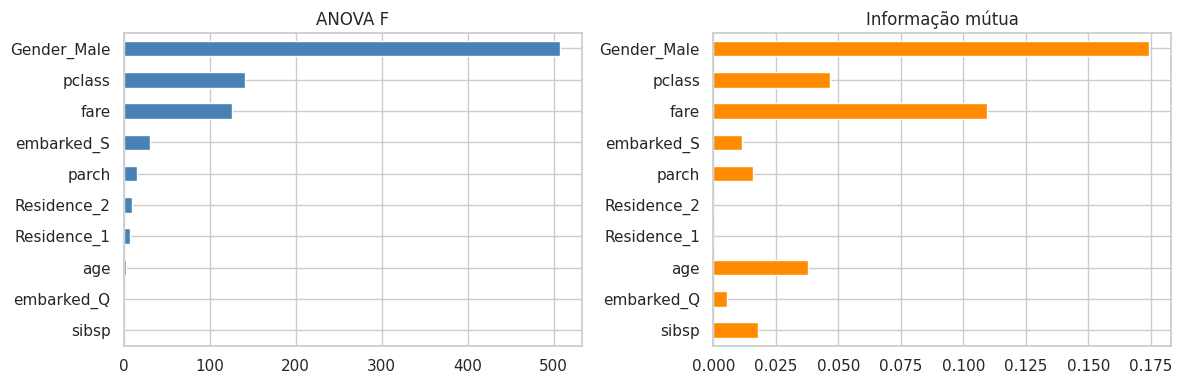

In [17]:
sel = SelectKBest(score_func=f_classif, k="all").fit(X_scaled, y)
mi = mutual_info_classif(X_scaled, y, random_state=SEED)

scores = pd.DataFrame({"F_score": sel.scores_, "p_valor": sel.pvalues_, "info_mutua": mi},
                      index=X_scaled.columns).sort_values("F_score", ascending=False)
display(scores.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
scores["F_score"].plot(kind="barh", ax=axes[0], color="steelblue"); axes[0].invert_yaxis(); axes[0].set_title("ANOVA F")
scores["info_mutua"].plot(kind="barh", ax=axes[1], color="darkorange"); axes[1].invert_yaxis(); axes[1].set_title("Informação mútua")
plt.tight_layout(); plt.show()

**Leitura dos resultados e decisão (k = 5 atributos):**

| Atributo | Decisão | Justificativa |
|---|---|---|
| `Gender_Male` | ✅ Incluir | De longe o mais informativo nos dois critérios. |
| `pclass` | ✅ Incluir | Forte relação com sobrevivência (1ª classe sobreviveu mais). |
| `fare` | ✅ Incluir | Alta pontuação; reflete poder aquisitivo (relacionada à classe). |
| `embarked_S` | ✅ Incluir | Pontuação F moderada e estatisticamente significativa. |
| `parch` | ✅ Incluir | Pontuação F moderada (p < 0,001). |
| `Residence_1/2` | ❌ Excluir | F baixo e informação mútua ≈ 0. |
| `age` | ❌ Excluir | F muito baixo (relação linear fraca); testamos incluí-la na seção 5.4. |
| `embarked_Q`, `sibsp` | ❌ Excluir | Pontuações próximas de zero. |

> **Observação metodológica:** `SelectKBest` usa `survived` para pontuar atributos, então há um uso do rótulo **na escolha das variáveis** (o K-Means em si continua não supervisionado). Isso é uma pequena "ajuda supervisionada" e deve ser levado em conta ao interpretar a acurácia final.

In [18]:
K_FEATURES = 5
selecionador = SelectKBest(score_func=f_classif, k=K_FEATURES).fit(X_scaled, y)
features_sel = list(X_scaled.columns[selecionador.get_support()])
print("Atributos selecionados:", features_sel)

X_sel = X_scaled[features_sel]

Atributos selecionados: ['pclass', 'parch', 'fare', 'Gender_Male', 'embarked_S']


****
## 5. K-Means

### 5.1 Testando diferentes valores de *k*

Rodamos o K-Means para *k* de 2 a 10 e guardamos duas medidas:

- **Inércia (WCSS)**: soma das distâncias quadráticas dos pontos ao centro do seu cluster. Quanto menor, mais compactos os clusters (mas sempre cai quando *k* aumenta).  
- **Silhouette**: de −1 a 1, mede quão bem separado e coeso é cada ponto no seu cluster. Quanto maior, melhor.

`n_init=10` roda o algoritmo 10 vezes com centros iniciais diferentes e fica com o melhor resultado.

,k,inercia,silhouette
0,2,4625.400,0.355
1,3,3622.241,0.366
2,4,2822.859,0.404
3,5,2326.974,0.439
4,6,1940.613,0.469
5,7,1718.674,0.512
6,8,1485.260,0.526
7,9,1337.874,0.544
8,10,1187.277,0.555


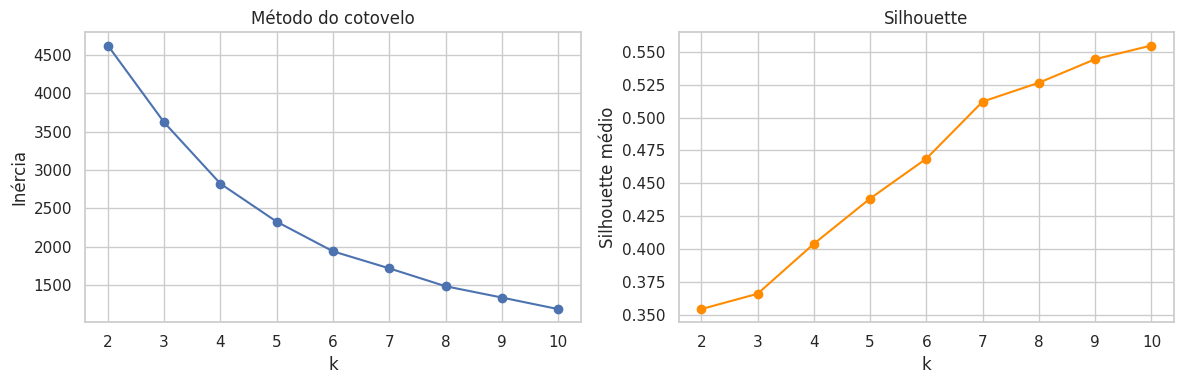

In [19]:
ks = range(2, 11)
inercias, silhuetas = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X_sel)
    inercias.append(km.inertia_)
    silhuetas.append(silhouette_score(X_sel, km.labels_))

resultado_k = pd.DataFrame({"k": list(ks), "inercia": inercias, "silhouette": silhuetas}).round(3)
display(resultado_k)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(ks), inercias, "o-"); axes[0].set_title("Método do cotovelo")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inércia")
axes[1].plot(list(ks), silhuetas, "o-", color="darkorange"); axes[1].set_title("Silhouette")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette médio")
plt.tight_layout(); plt.show()

### 5.2 Escolha de *k*

- **Cotovelo:** a inércia cai de forma **gradual**, sem um "joelho" bem marcado. A queda é mais forte até *k* = 3 ou 4 e depois suaviza.  
- **Silhouette:** cresce com *k*. Aqui isso é um **artefato dos dados**: com poucas variáveis, muitas delas binárias/discretas (sexo, classe, porto), existem poucas combinações distintas e clusters pequenos ficam "puros" facilmente. Por isso, o silhouette sozinho **não** é bom critério neste dataset.

**Decisão:**
- Para responder à pergunta do trabalho (**sobreviveu x não sobreviveu**, 2 classes), analisamos **k = 2**.  
- Pelo cotovelo, **k = 3** é um bom candidato "natural" e também é analisado.  

Comparamos os dois a seguir.

### 5.3 Clusters finais e comparação com `survived`

Como o K-Means numera clusters arbitrariamente (cluster 0 não significa "morreu"), para calcular acurácia precisamos **atribuir cada cluster a uma classe**. Usamos a regra da **maioria**: cada cluster recebe o rótulo (0 ou 1) mais frequente dentro dele.

Métricas usadas:
- **Acurácia, precisão, recall e F1** (após o mapeamento por maioria);  
- **ARI (Adjusted Rand Index)** e **NMI (Normalized Mutual Information)**: medem a concordância entre clusters e rótulos **sem precisar do mapeamento** (ARI ≈ 0 = concordância de acaso; 1 = perfeita).

In [20]:
def avaliar_clusters(Z, k, y, nome=""):
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(Z)
    labels = pd.Series(km.labels_, index=Z.index)
    # regra da maioria: cluster -> classe mais frequente
    mapa = (y.groupby(labels).mean() > 0.5).astype(int)
    pred = labels.map(mapa)
    out = {
        "conjunto": nome, "k": k,
        "acuracia": accuracy_score(y, pred),
        "precisao": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "f1": f1_score(y, pred, zero_division=0),
        "ARI": adjusted_rand_score(y, labels),
        "NMI": normalized_mutual_info_score(y, labels),
        "silhouette": silhouette_score(Z, labels),
    }
    return out, km, labels, pred

linha_base = max(y.mean(), 1 - y.mean())
print(f"Linha de base (sempre prever a classe majoritária): {linha_base:.3f}")

res2, km2, lab2, pred2 = avaliar_clusters(X_sel, 2, y, "SelectKBest (5)")
res3, km3, lab3, pred3 = avaliar_clusters(X_sel, 3, y, "SelectKBest (5)")
display(pd.DataFrame([res2, res3]).round(3))

Linha de base (sempre prever a classe majoritária): 0.618


,conjunto,k,acuracia,precisao,recall,f1,ARI,NMI,silhouette
0,SelectKBest (5),2,0.683,0.600,0.51,0.551,0.127,0.074,0.355
1,SelectKBest (5),3,0.725,0.606,0.80,0.690,0.202,0.133,0.366


#### Tabela cruzada: cluster × sobrevivência (k = 2)

survived,0,1,% sobreviveu
cluster,,,
0,639,245,27.7
1,170,255,60.0


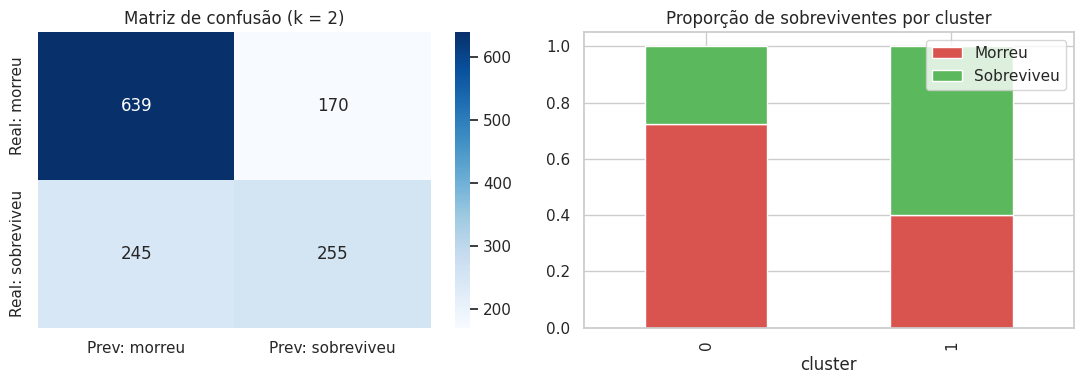

In [21]:
tab2 = pd.crosstab(lab2, y, rownames=["cluster"], colnames=["survived"])
tab2["% sobreviveu"] = (tab2[1] / tab2.sum(axis=1) * 100).round(1)
display(tab2)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(confusion_matrix(y, pred2), annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Prev: morreu", "Prev: sobreviveu"], yticklabels=["Real: morreu", "Real: sobreviveu"])
axes[0].set_title("Matriz de confusão (k = 2)")
pd.crosstab(lab2, y, normalize="index").plot(kind="bar", stacked=True, ax=axes[1], color=["#d9534f", "#5cb85c"])
axes[1].set_title("Proporção de sobreviventes por cluster"); axes[1].set_xlabel("cluster"); axes[1].legend(["Morreu", "Sobreviveu"])
plt.tight_layout(); plt.show()

#### Tabela cruzada: cluster × sobrevivência (k = 3)

In [22]:
tab3 = pd.crosstab(lab3, y, rownames=["cluster"], colnames=["survived"])
tab3["% sobreviveu"] = (tab3[1] / tab3.sum(axis=1) * 100).round(1)
display(tab3)

survived,0,1,% sobreviveu
cluster,,,
0,549,100,15.4
1,128,198,60.7
2,132,202,60.5


### 5.4 Comparando conjuntos de atributos

Para justificar a seleção feita na seção 4, comparamos o mesmo K-Means (k = 2) com três conjuntos de atributos: **todos**, os **5 selecionados** e os **3 mais fortes**.

> Cuidado ao comparar o *silhouette* entre conjuntos: com menos atributos o valor sobe quase sempre (menos dimensões = pontos mais "agrupáveis"), sem que isso signifique melhor relação com `survived`. As métricas contra o alvo (acurácia, ARI, NMI) são mais adequadas aqui.

In [23]:
conjuntos = {
    "Todos os atributos (10)": list(X_scaled.columns),
    "SelectKBest (5)": features_sel,
    "Top 3 (sexo, classe, tarifa)": ["Gender_Male", "pclass", "fare"],
    "Seleção (5) + age": features_sel + ["age"],
}
linhas = [avaliar_clusters(X_scaled[cols], 2, y, nome)[0] for nome, cols in conjuntos.items()]
comp = pd.DataFrame(linhas).drop(columns="k").round(3)
display(comp)

,conjunto,acuracia,precisao,recall,f1,ARI,NMI,silhouette
0,Todos os atributos (10),0.618,0.000,0.000,0.000,0.033,0.025,0.215
1,SelectKBest (5),0.683,0.600,0.510,0.551,0.127,0.074,0.355
2,"Top 3 (sexo, classe, tarifa)",0.678,0.611,0.434,0.508,0.116,0.065,0.504
3,Seleção (5) + age,0.669,0.589,0.442,0.505,0.105,0.057,0.324


### 5.5 Visualização dos clusters (PCA em 2D)

Como temos 5 dimensões, usamos **PCA** apenas para **desenhar** os pontos em 2D (o K-Means foi feito nas 5 dimensões originais). À esquerda, cores = cluster; à direita, cores = sobrevivência real. Se os grupos coincidissem com os rótulos, os dois gráficos seriam parecidos.

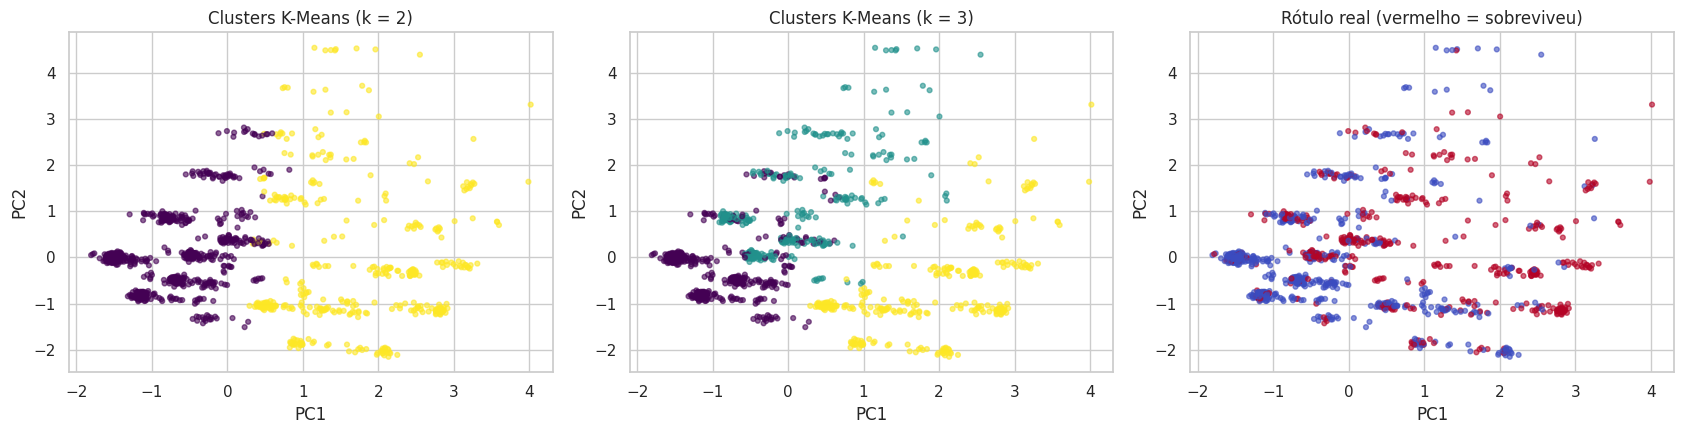

Variância explicada pelos 2 componentes: [0.384 0.227] = 0.611


In [24]:
pca = PCA(n_components=2, random_state=SEED)
P = pca.fit_transform(X_sel)
rng = np.random.default_rng(SEED)
Pj = P + rng.normal(0, 0.05, P.shape)   # pequeno ruído só para ver pontos sobrepostos (dados discretos)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, lab, titulo in [(axes[0], lab2, "Clusters K-Means (k = 2)"), (axes[1], lab3, "Clusters K-Means (k = 3)")]:
    sc = ax.scatter(Pj[:, 0], Pj[:, 1], c=lab, cmap="viridis", s=12, alpha=0.6)
    ax.set_title(titulo); ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
axes[2].scatter(Pj[:, 0], Pj[:, 1], c=y, cmap="coolwarm", s=12, alpha=0.6)
axes[2].set_title("Rótulo real (vermelho = sobreviveu)"); axes[2].set_xlabel("PC1"); axes[2].set_ylabel("PC2")
plt.tight_layout(); plt.show()
print("Variância explicada pelos 2 componentes:", pca.explained_variance_ratio_.round(3), "=", round(pca.explained_variance_ratio_.sum(), 3))

### 5.6 Perfil dos clusters (valores originais)

Para **interpretar** os clusters, olhamos as médias das variáveis nas escalas originais (antes da padronização).

In [25]:
def perfil(labels):
    d = df_tratado.copy()
    d["cluster"] = labels
    d["homem"] = (d["Gender"] == "Male").astype(int)
    g = d.groupby("cluster").agg(
        n=("survived", "size"),
        pct_sobreviveu=("survived", "mean"),
        pct_homem=("homem", "mean"),
        classe_media=("pclass", "mean"),
        tarifa_media=("fare", "mean"),
        idade_media=("age", "mean"),
        parch_medio=("parch", "mean"),
        pct_embarque_S=("embarked", lambda s: (s == "S").mean()),
    )
    return g.round(2)

print("Perfil dos clusters (k = 2):"); display(perfil(lab2))
print("Perfil dos clusters (k = 3):"); display(perfil(lab3))

Perfil dos clusters (k = 2):


,n,pct_sobreviveu,pct_homem,classe_media,tarifa_media,idade_media,parch_medio,pct_embarque_S
cluster,,,,,,,,
0,884,0.28,0.72,2.75,12.39,27.09,0.19,0.73
1,425,0.60,0.49,1.35,49.01,33.55,0.74,0.63


Perfil dos clusters (k = 3):


,n,pct_sobreviveu,pct_homem,classe_media,tarifa_media,idade_media,parch_medio,pct_embarque_S
cluster,,,,,,,,
0,649,0.15,1.00,2.73,12.61,27.57,0.17,0.78
1,326,0.61,0.02,2.68,17.87,25.18,0.72,0.69
2,334,0.60,0.56,1.07,53.21,36.24,0.42,0.56


****
## 6. Conclusões

> _Os números abaixo vêm da execução com `random_state=42`. Se rodar de novo e algo mudar, atualize esta seção._

**1. O que os clusters representam.** Com k = 2, os grupos separam principalmente **classe e tarifa**: o cluster 0 (884 passageiros) é de 3ª classe, tarifa média ~12, e o cluster 1 (425) é de classes altas (média 1,35), tarifa média ~49. Com k = 3, o **sexo** aparece com força: um cluster tem **100% homens** (só 15% sobreviveram), outro é quase só **mulheres** (98%, 61% sobreviveram) e o terceiro é de **1ª classe** com tarifa alta (60% sobreviveram). Isso é coerente com a história: "mulheres e crianças primeiro" e maior acesso aos botes para a 1ª classe.

**2. Os clusters se aproximam de sobreviventes x não sobreviventes?** Só **parcialmente**. Com k = 2, a acurácia ficou em torno de **68%**, contra **62%** da linha de base (sempre prever "morreu"). O ganho é pequeno (~6 pontos percentuais). A precisão foi ~0,60 e o recall ~0,51 para sobreviventes, ou seja, o modelo perde cerca de metade deles. O ARI (~0,13) e o NMI (~0,07) são **baixos**, indicando concordância fraca com os rótulos, ainda que melhor que o acaso. Um cluster ficou com taxa de sobrevivência de ~28% e o outro ~60%: uma separação real, mas **longe de perfeita**.

**3. k = 3.** É o melhor resultado: acurácia ~72%, recall ~0,80, ARI ~0,20 e NMI ~0,13. Parte da melhora é esperada, porque com mais clusters o mapeamento por maioria tem mais "liberdade" e tende a inflar a acurácia, mas ARI e NMI (que não dependem do mapeamento) também melhoraram, e o ganho vem de o K-Means isolar o grupo de **homens** (taxa de sobrevivência de apenas 15%). Mesmo assim, dois dos três clusters têm ~60% de sobreviventes, então a separação continua imperfeita.

**4. Seleção de atributos.** Usar todos os 10 atributos **piorou** a relação com `survived`: a acurácia caiu para ~62% (igual à linha de base, pois os dois clusters ficaram com maioria de "morreu", gerando precisão e recall zero) e o ARI para ≈ 0,03. Atributos pouco informativos (`Residence`, `sibsp`, `embarked_Q`, `age`) só adicionam ruído às distâncias. Os 5 selecionados deram o melhor resultado (acurácia 68,3%, ARI 0,13); o conjunto com só 3 atributos ficou muito próximo (67,8%), e adicionar `age` de volta piorou levemente (66,9%), o que apoia excluí-la.

**5. Escolha de k.** O cotovelo foi pouco marcado (queda gradual) e o silhouette cresce com k por efeito de variáveis discretas, então a escolha de k é em parte uma **decisão de interpretação** (k = 2 para comparar com o alvo binário; k = 3 como alternativa pelo cotovelo).

### Limitações do K-Means neste conjunto de dados

- **É não supervisionado:** otimiza compactação dos grupos, **não** a separação entre sobreviventes e não sobreviventes. Nada garante que os grupos "naturais" sejam os mesmos que o alvo.
- **Dados mistos e discretos:** boa parte dos atributos é binária ou categórica (sexo, porto, residência). O K-Means usa distância euclidiana e médias, que não são ideais para esse tipo de dado (alternativas: K-Modes ou K-Prototypes).
- **Clusters esféricos e de tamanho parecido:** o K-Means assume isso, e os dados do Titanic não têm essa estrutura.
- **Dados faltantes imputados:** ~20% das idades foram estimadas pela mediana do grupo, o que reduz a variabilidade real.
- **Efeito da seleção supervisionada:** o `SelectKBest` usou `survived`, o que pode favorecer levemente o resultado.
- **Interações importantes são perdidas:** a sobrevivência depende de combinações (ex.: mulher na 3ª classe x mulher na 1ª classe), que um algoritmo de agrupamento por distância captura mal. Um classificador supervisionado (árvore de decisão, regressão logística) tende a ir muito melhor.

**Conclusão geral:** o K-Means consegue recuperar parte da estrutura social do navio (sexo, classe, tarifa), que se relaciona com a sobrevivência, mas **não reproduz fielmente** a divisão entre sobreviventes e não sobreviventes (acurácia modesta e ARI baixo).

## 7. Referências

- Dataset Titanic: https://raw.githubusercontent.com/EMbeDS-education/IPDPP-GSSI-20202021/main/datasets/TITANIC.csv  
- Pedregosa et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR 12. Documentação de `KMeans`, `StandardScaler`, `SelectKBest`, `PCA`, `silhouette_score`, `adjusted_rand_score`, `normalized_mutual_info_score`: https://scikit-learn.org/stable/  
- Documentação do pandas (`read_csv`, `get_dummies`, `fillna`, `clip`): https://pandas.pydata.org/docs/  
- Material e anotações das aulas da disciplina.  
- _(Acrescentem aqui qualquer outra fonte que usarem.)_